In [13]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Connect to SQLite
# The path is relative to the notebook
conn = sqlite3.connect("../Data raw/Chinook_Sqlite.sqlite")

def run_query(query: str) -> pd.DataFrame:
    return pd.read_sql_query(query, conn)

import os
os.makedirs("../visualizations", exist_ok=True)

In [14]:
# SQL Queries Setup

with open("../SQL/analysis.sql", "r") as f:
    sql_script = f.read()

queries=[q.strip() for q  in sql_script.split(";") if q.strip()]
print(f"Found {len(queries)} queries")

Found 20 queries


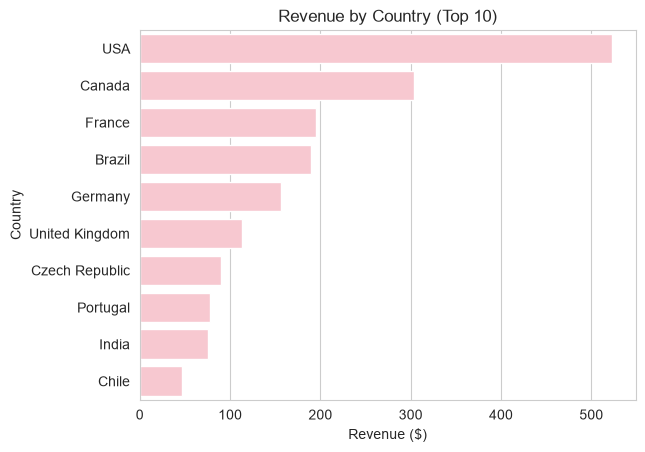

In [15]:
# 1. Revenue by Country

df_country_rev = run_query(queries[6])   # adjust index to match Query 7

sns.barplot(x='Revenue', y='Country', data=df_country_rev.head(10), color='pink')
plt.title('Revenue by Country (Top 10)')
plt.xlabel('Revenue ($)')
plt.ylabel('Country')
plt.savefig('../visualizations/revenue_by_country.png')
plt.show()

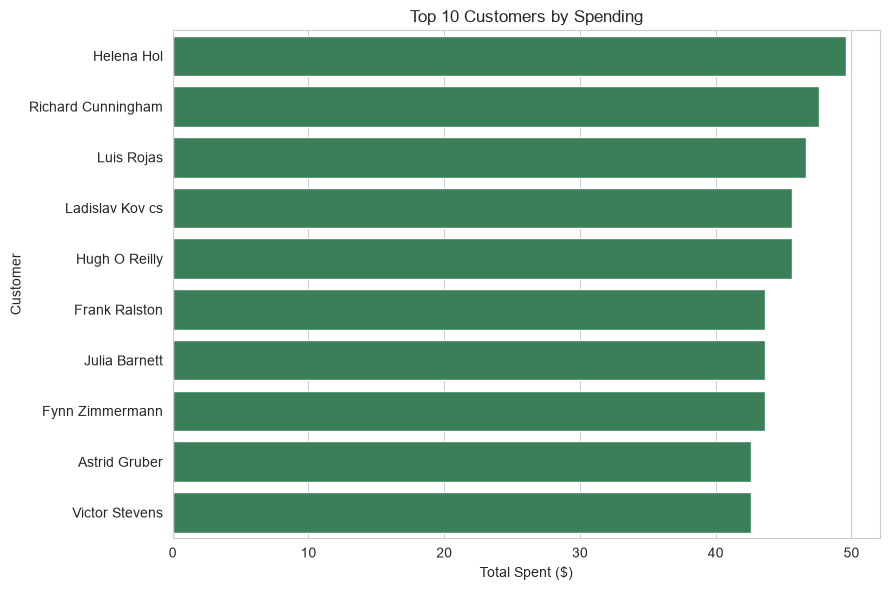

In [16]:
# 2. Top 10 Customers

df_top10_customers = run_query(queries[5])

df_top10_customers["CustomerName"] = (
    df_top10_customers["CustomerName"]
    .astype(str)
    .str.replace(r"[^A-Za-z]+", " ", regex=True)
    .str.strip()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x="TotalSpent",
    y="CustomerName",
    data=df_top10_customers,
    color="seagreen"
)

plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Spent ($)")
plt.ylabel("Customer")

plt.tight_layout()
plt.savefig("../visualizations/top_customers.png")
plt.show()

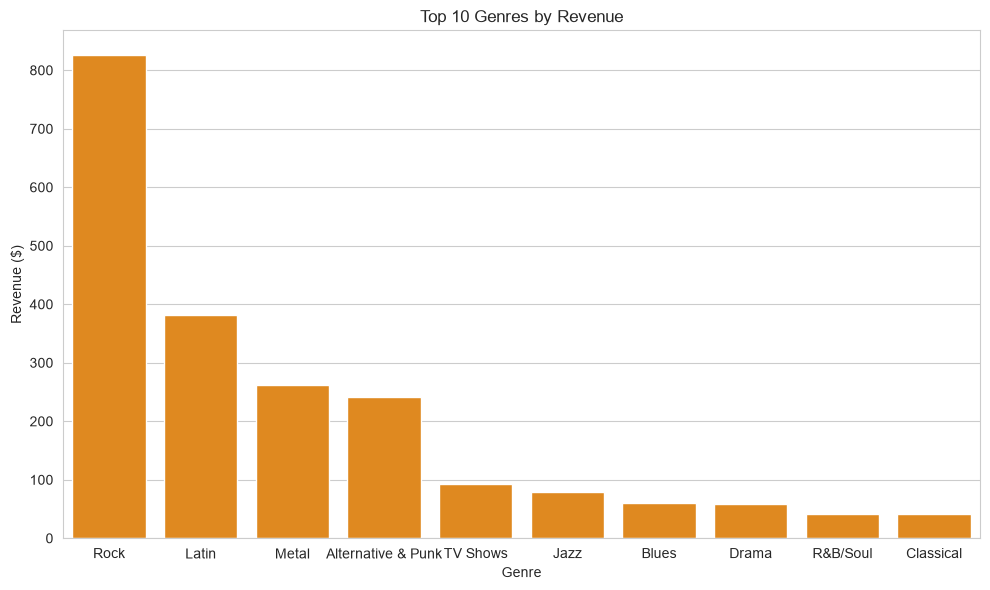

In [17]:
# 3. Revenue by Genre

df_genre_rev = run_query(queries[8]) # Index 8 = Query 9

plt.figure(figsize=(10,	6))
sns.barplot(x='Genre', y='Revenue', data =df_genre_rev.head(10), color='darkorange')
plt.title('Top 10 Genres by Revenue')
plt.xlabel('Genre')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('../visualizations/revenue_by_genre.png')
plt.show()

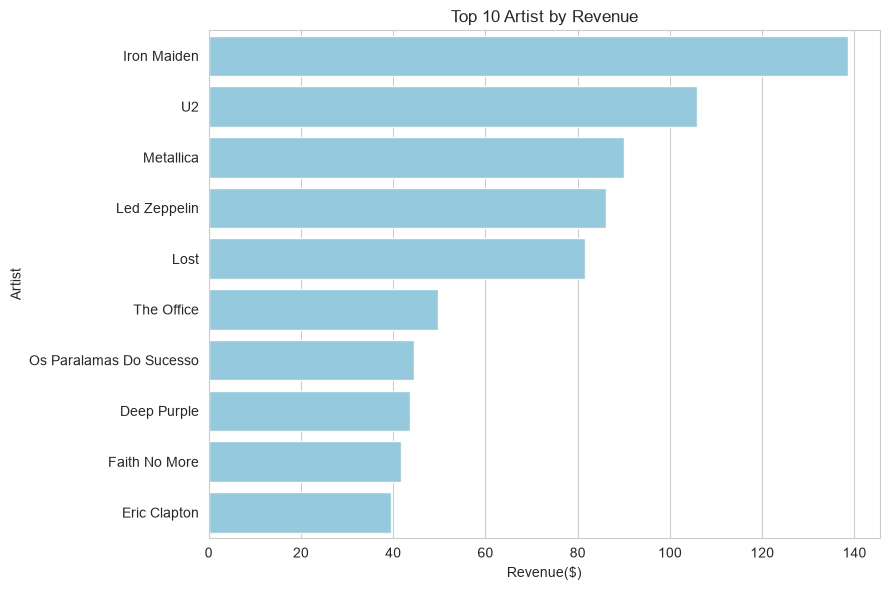

In [18]:
# 4. Top Artist 

df_top_artists = run_query(queries[9]) # adjust index to match query 10
plt.figure(figsize=(9,	6))
sns.barplot(x='Revenue',y='Artist',data=df_top_artists,	color='skyblue')
plt.title('Top 10 Artist by Revenue')
plt.xlabel('Revenue($)')
plt.ylabel('Artist')
plt.tight_layout()
plt.savefig('../visualizations/top_artists.png')
plt.show()

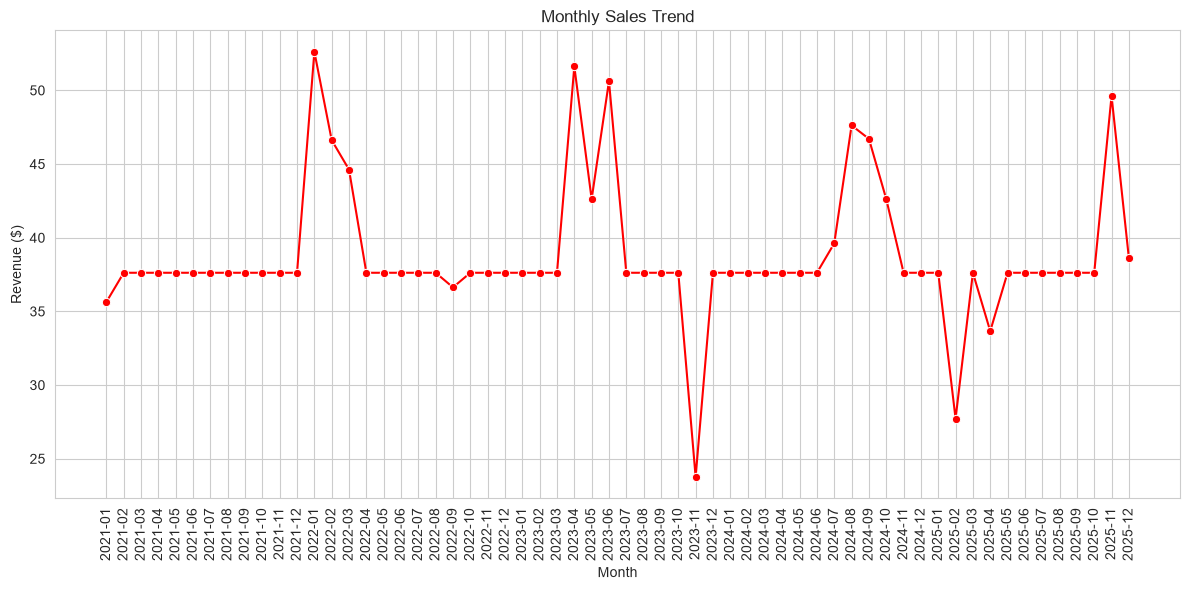

In [19]:
# 5. Monthly /Yearly Sales Trend

df_monthly = run_query(queries[12])   # adjust index to match Query 13

plt.figure(figsize=(12, 6))
sns.lineplot(x='YearMonth', y='Revenue', data=df_monthly, marker='o', color='red')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../visualizations/sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

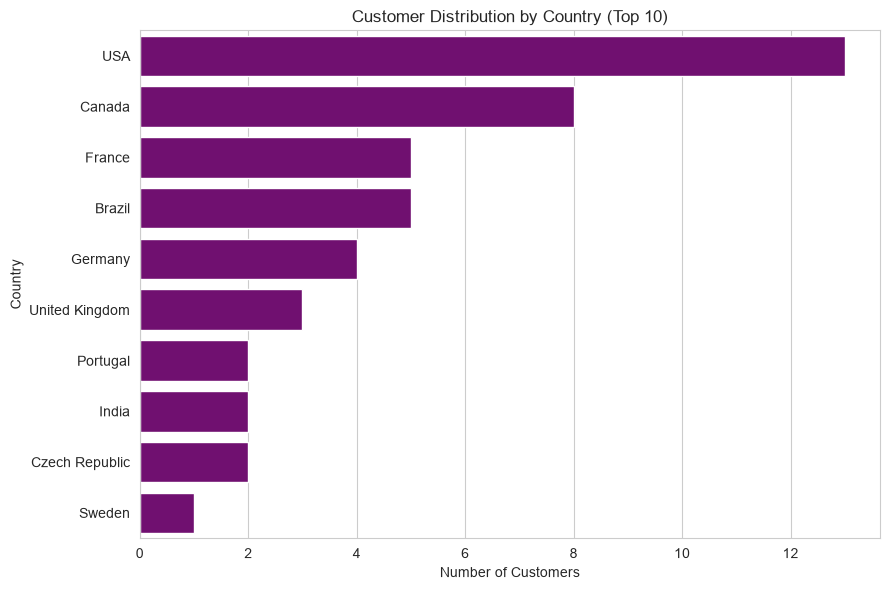

In [20]:
# 6. Customer Distribution by Country

df_cust_country = run_query(queries[7])   # adjust index to match Query 8

plt.figure(figsize=(9, 6))
sns.barplot(x='CustomerCount', y='Country', data=df_cust_country.head(10), color='purple')
plt.title('Customer Distribution by Country (Top 10)')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../visualizations/customer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
import os

os.makedirs("../Data raw/csv_export", exist_ok=True)

tables_to_export = ["Customer", "Invoice", "InvoiceLine", "Track", "Album", "Artist", "Genre"]

for t in tables_to_export:
    df = run_query(f"SELECT * FROM {t};")
    df.to_csv(f"../Data raw/csv_export/{t}.csv", index=False)
    print(f"Exported {t}: {df.shape[0]} rows")

Exported Customer: 59 rows
Exported Invoice: 412 rows
Exported InvoiceLine: 2240 rows
Exported Track: 3503 rows
Exported Album: 347 rows
Exported Artist: 275 rows
Exported Genre: 25 rows
